Task: Location-based Analysis
Objective: Perform a geographical analysis of the
restaurants in the dataset.

Steps:
Explore the latitude and longitude coordinates of
the restaurants and visualize their distribution on a
map.

Group the restaurants by city or locality and
analyze the concentration of restaurants in
different areas.

Calculate statistics such as the average ratings,
cuisines, or price ranges by city or locality.

Identify any interesting insights or patterns related
to the locations of the restaurants.

In [1]:
import pandas as pd 
import plotly.express as px
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


In [2]:
df=pd.read_csv('Dataset.csv')
df.columns

Index(['Restaurant ID', 'Restaurant Name', 'Country Code', 'City', 'Address',
       'Locality', 'Locality Verbose', 'Longitude', 'Latitude', 'Cuisines',
       'Average Cost for two', 'Currency', 'Has Table booking',
       'Has Online delivery', 'Is delivering now', 'Switch to order menu',
       'Price range', 'Aggregate rating', 'Rating color', 'Rating text',
       'Votes'],
      dtype='str')

In [3]:
#drop missing or zeroed values of latitute and longitude
geo_df=df[(df['Latitude']!=0)& (df['Longitude']!=0)].copy()
geo_df

,Restaurant ID,Restaurant Name,Country Code,City,Address,Locality,Locality Verbose,Longitude,Latitude,Cuisines,...,Currency,Has Table booking,Has Online delivery,Is delivering now,Switch to order menu,Price range,Aggregate rating,Rating color,Rating text,Votes
0,6317637,Le Petit Souffle,162,Makati City,"Third Floor, Century City Mall, Kalayaan Avenu...","Century City Mall, Poblacion, Makati City","Century City Mall, Poblacion, Makati City, Mak...",121.027535,14.565443,"French, Japanese, Desserts",...,Botswana Pula(P),Yes,No,No,No,3,4.8,Dark Green,Excellent,314
1,6304287,Izakaya Kikufuji,162,Makati City,"Little Tokyo, 2277 Chino Roces Avenue, Legaspi...","Little Tokyo, Legaspi Village, Makati City","Little Tokyo, Legaspi Village, Makati City, Ma...",121.014101,14.553708,Japanese,...,Botswana Pula(P),Yes,No,No,No,3,4.5,Dark Green,Excellent,591
2,6300002,Heat - Edsa Shangri-La,162,Mandaluyong City,"Edsa Shangri-La, 1 Garden Way, Ortigas, Mandal...","Edsa Shangri-La, Ortigas, Mandaluyong City","Edsa Shangri-La, Ortigas, Mandaluyong City, Ma...",121.056831,14.581404,"Seafood, Asian, Filipino, Indian",...,Botswana Pula(P),Yes,No,No,No,4,4.4,Green,Very Good,270
3,6318506,Ooma,162,Mandaluyong City,"Third Floor, Mega Fashion Hall, SM Megamall, O...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.056475,14.585318,"Japanese, Sushi",...,Botswana Pula(P),No,No,No,No,4,4.9,Dark Green,Excellent,365
4,6314302,Sambo Kojin,162,Mandaluyong City,"Third Floor, Mega Atrium, SM Megamall, Ortigas...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.057508,14.584450,"Japanese, Korean",...,Botswana Pula(P),Yes,No,No,No,4,4.8,Dark Green,Excellent,229
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9546,5915730,Namlı Gurme,208,İstanbul,"Kemankeş Karamustafa Paşa Mahallesi, Rıhtım Ca...",Karaköy,"Karaköy, İstanbul",28.977392,41.022793,Turkish,...,Turkish Lira(TL),No,No,No,No,3,4.1,Green,Very Good,788
9547,5908749,Ceviz Ağacı,208,İstanbul,"Koşuyolu Mahallesi, Muhittin Üstündağ Caddesi,...",Koşuyolu,"Koşuyolu, İstanbul",29.041297,41.009847,"World Cuisine, Patisserie, Cafe",...,Turkish Lira(TL),No,No,No,No,3,4.2,Green,Very Good,1034
9548,5915807,Huqqa,208,İstanbul,"Kuruçeşme Mahallesi, Muallim Naci Caddesi, No ...",Kuruçeşme,"Kuruçeşme, İstanbul",29.034640,41.055817,"Italian, World Cuisine",...,Turkish Lira(TL),No,No,No,No,4,3.7,Yellow,Good,661
9549,5916112,Aşık Kahve,208,İstanbul,"Kuruçeşme Mahallesi, Muallim Naci Caddesi, No ...",Kuruçeşme,"Kuruçeşme, İstanbul",29.036019,41.057979,Restaurant Cafe,...,Turkish Lira(TL),No,No,No,No,4,4.0,Green,Very Good,901


In [7]:
#map visualization using plotly
fig=px.scatter_geo(
    geo_df,
    lat='Latitude',
    lon='Longitude',
    color='Aggregate rating',
    size='Votes',
    hover_name='Restaurant Name',
    hover_data={
        'City':True,
        "Price range":True,
        'Votes':True,
        'Aggregate rating':True
    },
    projection='natural earth',
    title='GLOBAL RESTAURANT DISTRIBUTION AND RATING '
)
#customize map background ,coastline and natioanl boundry colors 
fig.update_layout(
    geo=dict(
        showland=True,
        landcolor='rgb(240,243,246)',
        countrycolor='rgb(189,195,199)',
        coastlinecolor='rgb(149,165,166)',
        showocean=True,
        showcountries=True

    )
)
fig.show()

In [8]:
df.columns

Index(['Restaurant ID', 'Restaurant Name', 'Country Code', 'City', 'Address',
       'Locality', 'Locality Verbose', 'Longitude', 'Latitude', 'Cuisines',
       'Average Cost for two', 'Currency', 'Has Table booking',
       'Has Online delivery', 'Is delivering now', 'Switch to order menu',
       'Price range', 'Aggregate rating', 'Rating color', 'Rating text',
       'Votes'],
      dtype='str')

In [16]:
# city level concentration
def get_dominant_cuisine(cuisine_series):
    cuisines_list=[c.strip() for item in cuisine_series.dropna() for c in str(item).split(',')]
    return pd.Series(cuisines_list).value_counts().index[0] if cuisines_list else 'N/a'
#group by city
city_summary =df.groupby('City').agg(
    Totalrestaurant=('Restaurant ID','count'),
    avgrating=('Aggregate rating','mean'),
    avgcostfortwo=('Average Cost for two','mean'),
    avgpricerange=('Price range','mean'),
    dominantcusisne=('Cuisines',get_dominant_cuisine)


).reset_index()
 #sort by restaurant 
top10cities=city_summary.sort_values(by='Totalrestaurant',ascending=False).head(10)
top10cities

,City,Totalrestaurant,avgrating,avgcostfortwo,avgpricerange,dominantcusisne
88,New Delhi,5473,2.438845,596.088069,1.621597,North Indian
50,Gurgaon,1118,2.651431,714.016100,1.855993,North Indian
89,Noida,1080,2.036204,539.490741,1.601852,North Indian
43,Faridabad,251,1.866932,447.609562,1.454183,North Indian
48,Ghaziabad,25,2.852000,602.000000,1.800000,North Indian
17,Bhubaneshwar,21,3.980952,678.571429,1.857143,Chinese
69,Lucknow,21,4.195238,859.523810,2.571429,Cafe
51,Guwahati,21,4.190476,821.428571,2.523810,Chinese
2,Ahmedabad,21,4.161905,857.142857,2.571429,Continental
5,Amritsar,21,3.685714,480.952381,1.809524,North Indian


In [18]:
#locality
locality_summary=df.groupby(['City','Locality']).agg(
    Totalrestaurant=('Restaurant ID','count'),
        avgrating=('Aggregate rating','mean'),
        avgpricerange=('Price range','mean')
    
).reset_index()
top10locality=locality_summary.sort_values(by='Totalrestaurant',ascending=False).head(10)
top10locality

,City,Locality,Totalrestaurant,avgrating,avgpricerange
712,New Delhi,Connaught Place,122,3.686885,2.598361
860,New Delhi,Rajouri Garden,99,3.591919,2.202020
873,New Delhi,Shahdara,87,1.413793,1.137931
725,New Delhi,Defence Colony,86,3.210465,1.930233
846,New Delhi,Pitampura,85,2.870588,1.470588
812,New Delhi,Mayur Vihar Phase 1,84,2.026190,1.297619
807,New Delhi,Malviya Nagar,84,3.417857,1.773810
859,New Delhi,Rajinder Nagar,81,2.943210,1.432099
864,New Delhi,Safdarjung,80,2.801250,1.675000
870,New Delhi,Satyaniketan,79,3.482278,1.620253


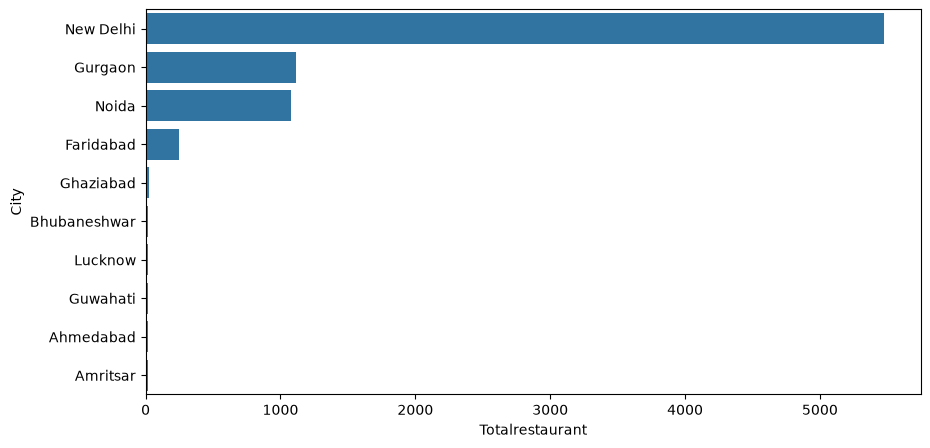

In [19]:
#visualization
plt.figure(figsize=(10,5))
sns.barplot(data=top10cities,x='Totalrestaurant',y='City')
plt.show()